In [11]:
import xgboost as xgb
import pandas as pd
import sklearn
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import cross_val_score, KFold, train_test_split, TimeSeriesSplit
from sklearn.metrics import r2_score
import warnings 
from pmdarima import auto_arima 
from statsmodels.tsa.arima.model import ARIMA

In [2]:
df = pd.read_csv('../dataset_1_pixels_grid_indices.csv')
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(['row', 'col', 'date'])

df = df.sort_values('date').reset_index(drop=True)

In [17]:
def rolling_window_cv(train_days, gap_days, test_days, df, model):
    dates = df["date"].unique()
    train_start = 0
    num_days = len(dates)
    i = 1
    errors = []

    while True:
        train_end = train_start + train_days
        test_start = train_end + gap_days
        test_end = test_start + test_days

        if test_end > num_days:
            break

        train_dates = dates[train_start: train_end]
        test_dates = dates[test_start: test_end]

        print(f'Fold {i}')
        print(train_dates.min(), train_dates.max())
        print(test_dates.min(), test_dates.max())

        train_data =  df[df["date"].isin(train_dates)]
        test_data = df[df["date"].isin(test_dates)]

        X_train = train_data.drop(['date', 'pm25_change'], axis=1)
        y_train = train_data['pm25_change']

        X_test = test_data.drop(['date', 'pm25_change'], axis=1)
        y_test = test_data['pm25_change']
        
        model.fit(X_train, y_train)

        y_preds = model.predict(X_test)

        mse = mean_squared_error(y_test, y_preds)
        rmse = root_mean_squared_error(y_test, y_preds)
        r2 = r2_score(y_test, y_preds)

        errors.append(r2)

        print(f"MSE: {mse}")
        print(f"RMSE: {rmse}")
        print(f"R^2: {r2}")
        train_start += test_days
        i += 1

    print(np.mean(errors))


In [26]:
model = xgb.XGBRegressor(eta=0.04)

rolling_window_cv(train_days=1100, gap_days=10, test_days=20, df=df, model=model)

Fold 1
2018-07-04 00:00:00 2021-08-04 00:00:00
2021-08-15 00:00:00 2021-09-03 00:00:00
MSE: 0.9420042899254805
RMSE: 0.9705690546918753
R^2: 0.022224932698785893
Fold 2
2018-07-24 00:00:00 2021-08-24 00:00:00
2021-09-04 00:00:00 2021-09-23 00:00:00
MSE: 1.2522560564389578
RMSE: 1.1190424730272563
R^2: -0.06231314039511959
Fold 3
2018-08-13 00:00:00 2021-09-13 00:00:00
2021-09-24 00:00:00 2021-10-13 00:00:00
MSE: 2.3925488577512684
RMSE: 1.5467866232131917
R^2: 0.03090411456598252
Fold 4
2018-09-02 00:00:00 2021-10-03 00:00:00
2021-10-14 00:00:00 2021-11-02 00:00:00
MSE: 3.7832238549378907
RMSE: 1.9450511188495512
R^2: -0.01613986045232929
Fold 5
2018-09-22 00:00:00 2021-10-23 00:00:00
2021-11-03 00:00:00 2021-11-22 00:00:00
MSE: 9.549528265034844
RMSE: 3.090231102204954
R^2: 0.056215685492714274
Fold 6
2018-10-12 00:00:00 2021-11-12 00:00:00
2021-11-23 00:00:00 2021-12-12 00:00:00
MSE: 14.128099536983076
RMSE: 3.758736428240623
R^2: 0.019966817093250655
Fold 7
2018-11-01 00:00:00 2021-

In [4]:
warnings.filterwarnings("ignore") 

df_filtered = df[(df["row"] == 10) & (df["col"] == 10)].sort_values("date").set_index("date")
  
# Fit auto_arima function to AirPassengers dataset 
stepwise_fit = auto_arima(df_filtered["pm25_change"], start_p = 1, start_q = 1, 
                          max_p = 3, max_q = 3, m = 12, 
                          start_P = 0, seasonal = True, 
                          d = None, D = 1, trace = True, 
                          error_action ='ignore',   # we don't want to know if an order does not work 
                          suppress_warnings = True,  # we don't want convergence warnings 
                          stepwise = True)           # set to stepwise 
  
# To print the summary 
stepwise_fit.summary() 

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=3.17 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=12194.654, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=11773.568, Time=0.57 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=1.75 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=12192.654, Time=0.03 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=12159.658, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=11609.640, Time=2.11 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=7.50 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=1.82 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=11632.779, Time=1.03 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=11578.635, Time=2.42 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=11747.365, Time=0.85 sec
 ARIMA(2,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=9.00 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=3.07 sec
 ARIMA(3,0,0)(2,1,0)[12] intercept   : AI

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                 1598
Model:             SARIMAX(3, 0, 0)x(2, 1, 0, 12)   Log Likelihood               -5750.503
Date:                            Wed, 23 Apr 2025   AIC                          11513.005
Time:                                    23:08:39   BIC                          11545.219
Sample:                                         0   HQIC                         11524.973
                                           - 1598                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1740      0.010    -17.950      0.000      -0.193      -0.155
ar.L2         -0.1729      0.012    -14.854      0.000      -0.196      -0.150
ar.L3         -0.2021      0.012    -16.792      0.000      -0.226      -0.179
ar.S.L12      -0.5943      0.011    -53.302      0.000      -0.616      -0.572
ar.S.L24      -0.3112      0.013    -24.589      0.000      -0.336      -0.286
sigma2        82.2944      1.006     81.808      0.000      80.323      84.266
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):             18288.44
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               0.72   Skew:                            -0.80
Prob(H) (two-sided):                  0.00   Kurtosis:                        19.56
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

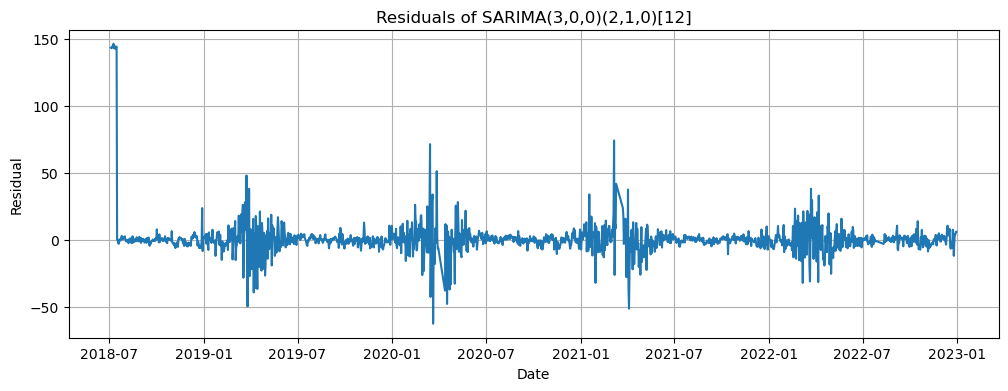

In [8]:
model = SARIMAX(df_filtered["pm25_change"], exog=df_filtered.drop("pm25_change", axis=1), order=(3, 0, 0), seasonal_order=(2, 1, 0, 12))
results = model.fit()

# Plot residuals
residuals = results.resid

plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.title("Residuals of SARIMA(3,0,0)(2,1,0)[12]")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

In [16]:
df_filtered = df
dates = df_filtered["date"].unique()

train_days = 100
gap_days = 14
test_days = 62

train_start = 0

num_days = len(dates)
i = 1

errors = []
while True:
    train_end = train_start + train_days
    test_start = train_end + gap_days
    test_end = test_start + test_days

    if test_end > num_days:
        break

    train_dates = dates[train_start: train_end]
    test_dates = dates[test_start: test_end]

    print(f'Fold {i}')
    print(train_dates.min(), train_dates.max())
    print(test_dates.min(), test_dates.max())

    train_data =  df[df["date"].isin(train_dates)]
    test_data = df[df["date"].isin(test_dates)]

    train = train_data[["pm25_change", "date"]].sort_values('date').set_index('date')
    test = test_data[["pm25_change", "date"]].sort_values('date').set_index('date')

    model = ARIMA(train, order=(1, 0, 1))
    fitted_model = model.fit()

    # Train-test split
    train_len = len(train)
    test_len = len(test)

    # Predict using integer positions
    y_preds = fitted_model.predict(start=train_len, end=train_len + test_len - 1)

    # y_preds = np.zeros_like(y_test)

    mse = mean_squared_error(test, y_preds)
    rmse = root_mean_squared_error(test, y_preds)
    r2 = r2_score(test, y_preds)

    errors.append(r2)

    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R^2: {r2}")
    train_start += test_days
    i += 1

print(np.mean(errors))


Fold 1
2018-07-04 00:00:00 2018-10-11 00:00:00
2018-10-26 00:00:00 2018-12-26 00:00:00
MSE: 6.997265999613797
RMSE: 2.6452345830972717
R^2: -0.002269946935788303
Fold 2
2018-09-04 00:00:00 2018-12-12 00:00:00
2018-12-27 00:00:00 2019-02-28 00:00:00
MSE: 55.61076351861404
RMSE: 7.45726246813226
R^2: 0.005225505614489534
Fold 3
2018-11-05 00:00:00 2019-02-14 00:00:00
2019-03-01 00:00:00 2019-05-01 00:00:00
MSE: 608.7380402531583
RMSE: 24.672617215308925
R^2: -0.0004216942477277552
Fold 4
2019-01-06 00:00:00 2019-04-17 00:00:00
2019-05-02 00:00:00 2019-07-02 00:00:00
MSE: 24.284175515507652
RMSE: 4.927897677053335
R^2: -0.01877312719473534
Fold 5
2019-03-11 00:00:00 2019-06-18 00:00:00
2019-07-03 00:00:00 2019-09-02 00:00:00


KeyboardInterrupt: 

In [40]:
df_filtered = df
dates = df_filtered["date"].unique()

train_days = 800
gap_days = 14
test_days = 62

train_start = 0

num_days = len(dates)
i = 1

errors = []
while True:
    train_end = train_start + train_days
    test_start = train_end + gap_days
    test_end = test_start + test_days

    if test_end > num_days:
        break

    train_dates = dates[train_start: train_end]
    test_dates = dates[test_start: test_end]

    print(f'Fold {i}')
    print(train_dates.min(), train_dates.max())
    print(test_dates.min(), test_dates.max())

    train_data =  df[df["date"].isin(train_dates)]
    test_data = df[df["date"].isin(test_dates)]

    X_train = train_data.drop(['date', 'pm25_change'], axis=1)
    y_train = train_data['pm25_change']

    X_test = test_data.drop(['date', 'pm25_change'], axis=1)
    y_test = test_data['pm25_change']

    model = xgb.XGBRegressor(eta=0.03)
    model.fit(X_train, y_train)

    y_preds = model.predict(X_test)

    # y_preds = np.zeros_like(y_test)

    mse = mean_squared_error(y_test, y_preds)
    rmse = root_mean_squared_error(y_test, y_preds)
    r2 = r2_score(y_test, y_preds)

    errors.append(r2)

    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R^2: {r2}")
    train_start += test_days
    i += 1

print(np.mean(errors))


Fold 1
2018-07-04 00:00:00 2020-09-26 00:00:00
2020-10-11 00:00:00 2020-12-11 00:00:00
MSE: 26.73277582907139
RMSE: 5.170374824814096
R^2: 0.2021646926837889
Fold 2
2018-09-04 00:00:00 2020-11-27 00:00:00
2020-12-12 00:00:00 2021-02-11 00:00:00
MSE: 54.228042203955525
RMSE: 7.363969188145448
R^2: 0.11807893012577997
Fold 3
2018-11-05 00:00:00 2021-01-28 00:00:00
2021-02-12 00:00:00 2021-04-26 00:00:00
MSE: 154.28674327221535
RMSE: 12.42122148873513
R^2: 0.1909333030490925
Fold 4
2019-01-06 00:00:00 2021-04-12 00:00:00
2021-04-27 00:00:00 2021-06-27 00:00:00
MSE: 5.5348312636885995
RMSE: 2.352622210149475
R^2: 0.11320565254111248
Fold 5
2019-03-11 00:00:00 2021-06-13 00:00:00
2021-06-28 00:00:00 2021-08-28 00:00:00
MSE: 1.0232347073052501
RMSE: 1.0115506449532075
R^2: -0.03328081653702086
Fold 6
2019-05-12 00:00:00 2021-08-14 00:00:00
2021-08-29 00:00:00 2021-10-29 00:00:00
MSE: 2.3405142065725975
RMSE: 1.5298739185215877
R^2: 0.000479727688573961
Fold 7
2019-07-13 00:00:00 2021-10-15 0